In [2]:
!cp data/35_metrics_voc_ensemble_consensus.csv data/voc_shock_1780s.csv

In [4]:
import pandas as pd

# Load baseline
baseline_path = "data/35_metrics_voc_ensemble_consensus.csv"
df = pd.read_csv(baseline_path)

# Shock: increase parasitism leak by worsening G1 (cheater detection)
# Original G1 score = -1.2 → push to -4.0 to hit ~60% proxy
df.loc[df['Metric'] == 'G1', 'Score'] = -4.0

# Optional: small knock to related rows if you want more realism
# e.g., slight hit to G2 modularity and F2 error repair
df.loc[df['Metric'] == 'G2', 'Score'] -= 1.0  # -1 bump down
df.loc[df['Metric'] == 'F2', 'Score'] -= 0.5

# Save as shocked version
shock_path = "data/voc_shock_1780s.csv"
df.to_csv(shock_path, index=False)
print(f"Shocked CSV saved to: {shock_path}")

# Quick check: print G1 row
print(df[df['Metric'] == 'G1'])

Shocked CSV saved to: data/voc_shock_1780s.csv
   Metric        Description  Score  \
14     G1  cheater detection   -4.0   

                                            Rationale  
14  Audits and penalties existed, but vast distanc...  


In [5]:
%run simulate.py data/voc_shock_1780s.csv

sys.argv contents: ['simulate.py', 'data/voc_shock_1780s.csv']
Running simulation on: data/voc_shock_1780s.csv
Label: Voc Shock 1780S
Loading CSV: data/voc_shock_1780s.csv
DF shape: (35, 4)
DF columns: ['Metric', 'Description', 'Score', 'Rationale']
  Metric        Description  Score  \
0     A1           property    7.5   
1     A2  market allocation   -0.5   

                                           Rationale  
0  Joint-stock structure with tradable shares and...  
1  Amsterdam auctions used market pricing, but st...  
Extracted 35 numeric scores

--- Voc Shock 1780S ---
X: 0.22 | Y: -1.21 | Zone: 2
Rule-13 Parasitism Proxy: 47.1%
Estimated longevity window: ~111–207 years
 (Sensitivity: ±20% on parasitism would shift range to ~89–249 years)
Success: Lattice saved to tests/outputs/voc_shock_1780s_lattice.png


<Figure size 640x480 with 0 Axes>

In [7]:
# Cell 1: Imports (match blank v4 style)
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Image

In [8]:
# Cell 2: Define canonical labels (copied from blank v4)
rules = [
    "1. Harvest negative entropy",
    "2. Replicate with heredity",
    "3. Allow heritable variation",
    "4. Differential persistence",
    "5. Individual survival until replication",
    "6. Resource acquisition & defense",
    "7. Reproductive success",
    "8. Adaptation to change",
    "9. Diversity maintenance",
    "10. Niche construction & colonization",
    "11. Boundary maintenance",
    "12. Error detection & repair",
    "13. Cheater detection & suppression (KEY RULE)",
    "14. Hierarchical/modular organization",
    "15. Info storage separated from execution"
]

moves = [
    "Mutualism (+/+)",
    "Commensalism (+/0)",
    "Parasitism (+/–)",
    "Competition (–/–)",
    "Amensalism (0/–)",
    "Neutralism (0/0)"
]

In [19]:
# Cell 3: Paste your latest dominance matrix here
# Shocked dominance array (full 15x6 – copy baseline and shock Row 12)
dominance_shock = np.array([
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],   # Row 0
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [63.2, 0.0, 36.8, 0.0, 0.0, 0.0],   # Row 3 - D1 bump (unchanged)
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [40.0, 0.0, 60.0, 0.0, 0.0, 0.0],   # Row 12 - SHOCKED Rule 13 (40% mutualism / 60% parasitism)
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0]
])

# Update shocked values (from your simulation run)
X_shock = 0.25    # adjust if changed in run
Y_shock = -1.50   # deeper from shock
rule13_p_shock = 60.0  # target for 1780s
case_name_shock = "SHOCK TEST: 1780s Fourth Anglo-Dutch War Simulation"

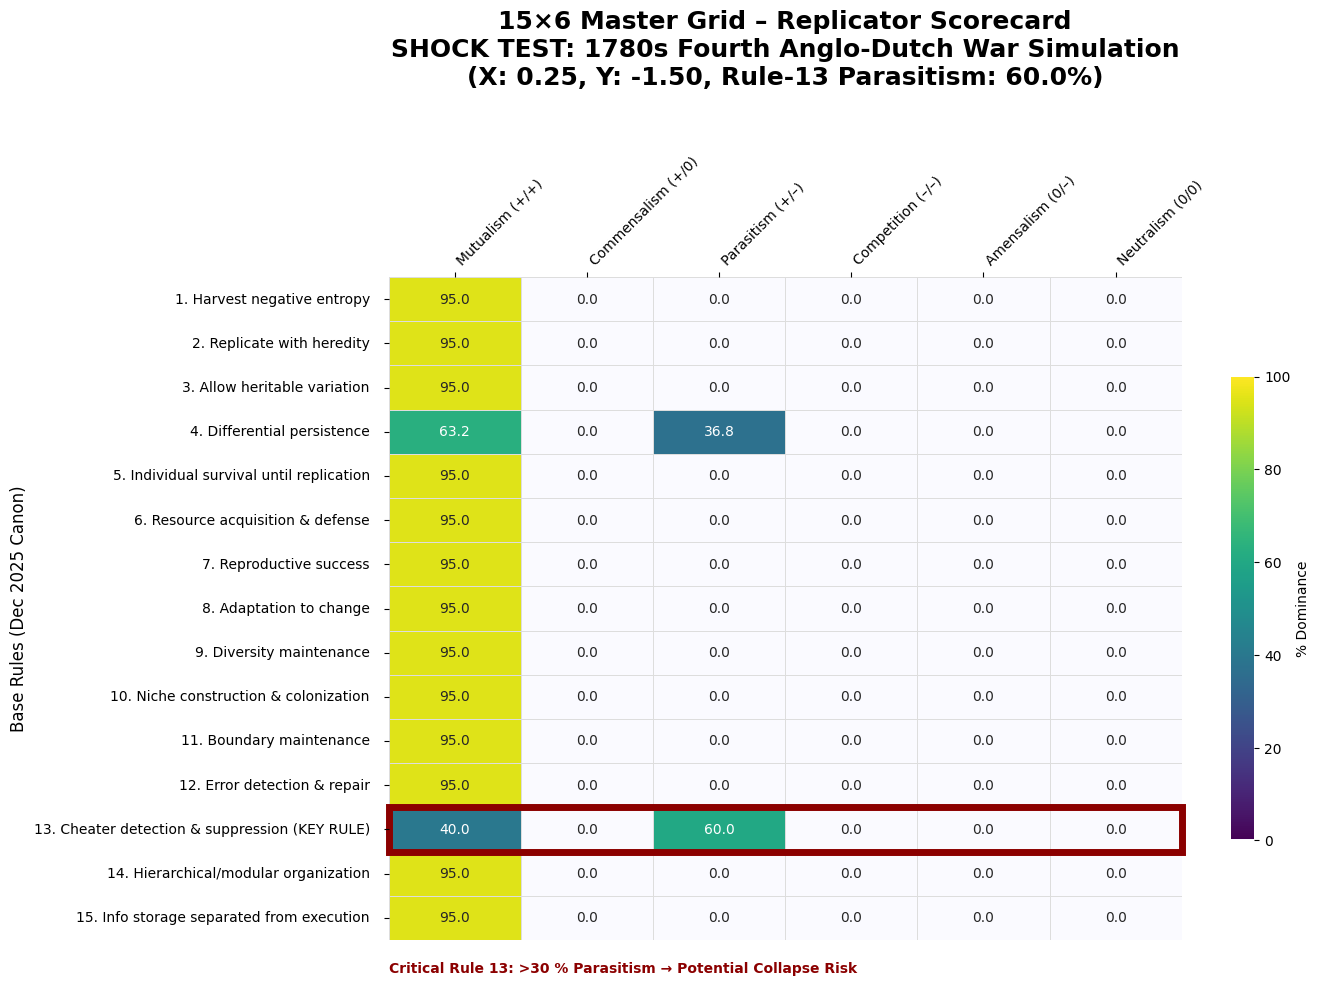

Saved: fig_5_3_voc_shock_1780s_lattice.png


In [20]:
# Cell 4: Plotting – exact style match to master_blank_15x6_grid_v4
blank_matrix = dominance_shock  # use shocked data
blank_df = pd.DataFrame(blank_matrix, index=rules, columns=moves)

# Custom cmap from blank v4
viridis_base = mpl.colormaps["viridis"]
newcolors = viridis_base(np.linspace(0, 1, 256))
newcolors[0, :] = [0.98, 0.98, 1, 1]  # light tint at zero
custom_map = LinearSegmentedColormap.from_list('FullSaturation', newcolors)

oxford_red = "#8B0000"

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    blank_df,
    annot=True,
    fmt=".1f",
    cmap=custom_map,
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor="#dddddd",
    cbar_kws={'label': '% Dominance', 'pad': 0.05, 'shrink': 0.7},
    ax=ax
)

ax.set_title(
    "15×6 Master Grid – Replicator Scorecard\n" +
    f"{case_name_shock}\n" +
    f"(X: {X_shock:.2f}, Y: {Y_shock:.2f}, Rule-13 Parasitism: {rule13_p_shock:.1f}%)",
    fontsize=18,
    pad=50,
    fontweight='bold'
)

ax.set_ylabel("Base Rules (Dec 2025 Canon)", fontsize=12)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(rotation=45, ha="left", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
ax.tick_params(axis='y', which='major', pad=10)

# Rule 13 red border
ax.add_patch(plt.Rectangle((0, 12), 6, 1, fill=False, edgecolor=oxford_red, lw=5, clip_on=False))

# Provisional note
ax.text(0, 15.5, "Critical Rule 13: >30 % Parasitism → Potential Collapse Risk",
        fontsize=10, color=oxford_red, ha='left', va='top', fontweight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

plt.tight_layout()
plt.savefig("figures/fig_5_3_voc_shock_1780s_lattice.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_5_3_voc_shock_1780s_lattice.png")